# 1. Introduction
# Global Weather Trend Forecasting 
### By Riddhi Patel for PM Accelerator Internship Program


## Objective
The goal of this project is to analyze global weather data and forecast temperature trends using machine learning techniques.

## Dataset
The dataset contains daily weather observations across multiple cities worldwide, including:
- Temperature
- Humidity
- Wind speed
- Air quality
- Pressure
- UV index
- Geographic data

## Key Goals
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Identify trends and patterns
- Build forecasting models
- Evaluate performance
- Generate insights

## PM Accelerator Mission
PM Accelerator empowers individuals with hands-on, real-world projects to develop strong technical and analytical skills.

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor

# 3. Load Data

In [2]:
df = pd.read_csv("data/GlobalWeatherRepository.csv")
df.columns = df.columns.str.lower().str.strip()
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_pm2.5,air_quality_pm10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


# 4. Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130198 entries, 0 to 130197
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       130198 non-null  object 
 1   location_name                 130198 non-null  object 
 2   latitude                      130198 non-null  float64
 3   longitude                     130198 non-null  float64
 4   timezone                      130198 non-null  object 
 5   last_updated_epoch            130198 non-null  int64  
 6   last_updated                  130198 non-null  object 
 7   temperature_celsius           130198 non-null  float64
 8   temperature_fahrenheit        130198 non-null  float64
 9   condition_text                130198 non-null  object 
 10  wind_mph                      130198 non-null  float64
 11  wind_kph                      130198 non-null  float64
 12  wind_degree                   130198 non-nul

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_carbon_monoxide,air_quality_ozone,air_quality_nitrogen_dioxide,air_quality_sulphur_dioxide,air_quality_pm2.5,air_quality_pm10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,130198.000000,130198.000000,1.301980e+05,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,...,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000,130198.000000
mean,19.203636,21.976217,1.744821e+09,21.398962,70.519917,8.042283,12.946403,168.941151,1014.098074,29.945681,...,18.295291,468.691789,58.439086,15.136501,10.524859,24.451573,48.937473,1.706616,2.624265,49.653881
std,24.420357,65.788805,1.671608e+07,9.689675,17.441266,7.294333,11.735952,103.584996,10.492201,0.309800,...,13.918412,769.464396,30.956254,23.975924,36.288091,37.377032,150.903511,0.946227,2.460585,35.042860
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730365e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,207.200000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.744880e+09,24.000000,75.200000,6.900000,11.200000,161.000000,1014.000000,29.930000,...,15.400000,299.700000,55.100000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759304e+09,28.000000,82.400000,11.000000,17.600000,255.750000,1018.000000,30.060000,...,24.300000,467.300000,74.000000,17.575000,8.510000,28.050000,41.850000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.773816e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


# 5. Data Cleaning

In [4]:
# Convert datetime
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

# Drop missing date rows
df = df.dropna(subset=['last_updated'])

# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

0

# 6. Outlier Removal

In [5]:
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['temperature_celsius'] >= Q1 - 1.5 * IQR) &
        (df['temperature_celsius'] <= Q3 + 1.5 * IQR)]

# 7. Feature Engineering

In [6]:
df = df.sort_values('last_updated')

df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

# Lag features
df['temp_lag_1'] = df['temperature_celsius'].shift(1)

df = df.dropna()

# 8. Remove Leakage Features

In [7]:
df = df.drop(columns=[
    'country','location_name','timezone','condition_text',
    'wind_direction','sunrise','sunset','moonrise','moonset','moon_phase',
    'temperature_fahrenheit',
    'feels_like_celsius',
    'feels_like_fahrenheit'
], errors='ignore')

# 9. Exploratory Data Analysis (EDA)

### Temperature Trend

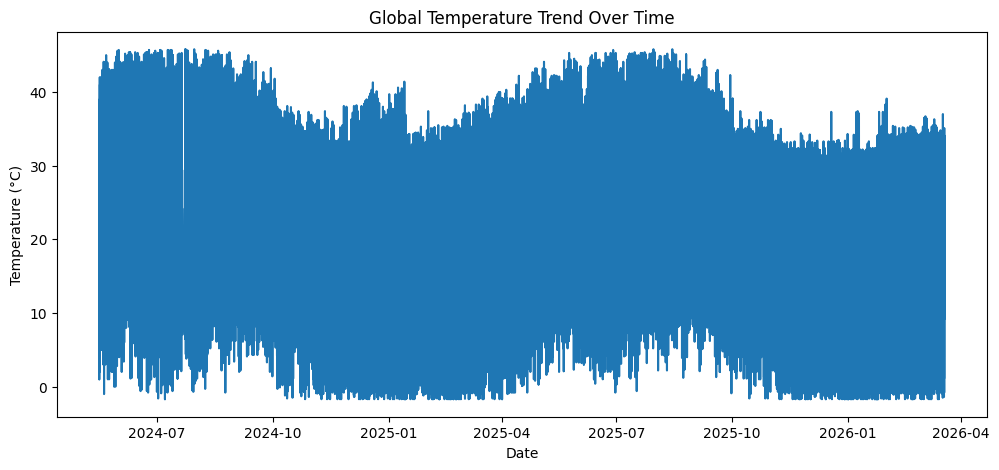

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['last_updated'], df['temperature_celsius'])
plt.title("Global Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

#### Temperature fluctuates significantly over time, reflecting seasonal and regional variations.

### Precipitation Trend

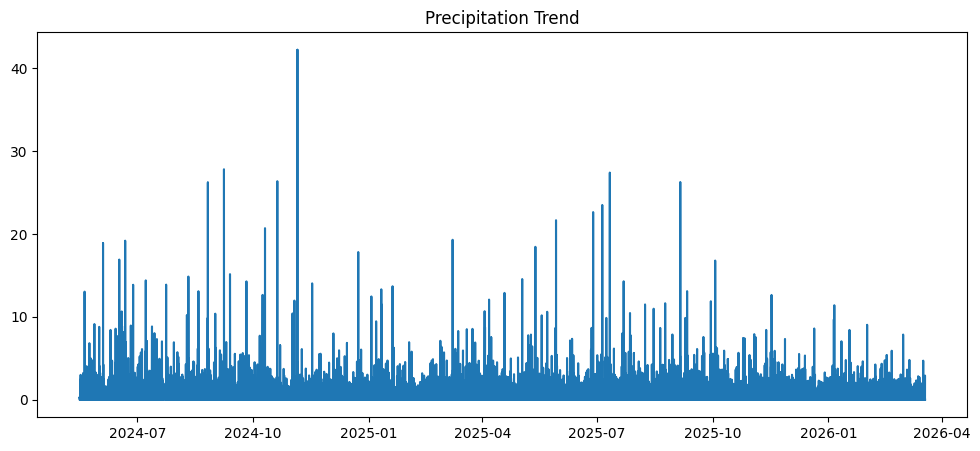

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df['last_updated'], df['precip_mm'])
plt.title("Precipitation Trend")
plt.show()

#### Rainfall patterns vary widely, indicating climate diversity across regions.

### Correlation Heatmap

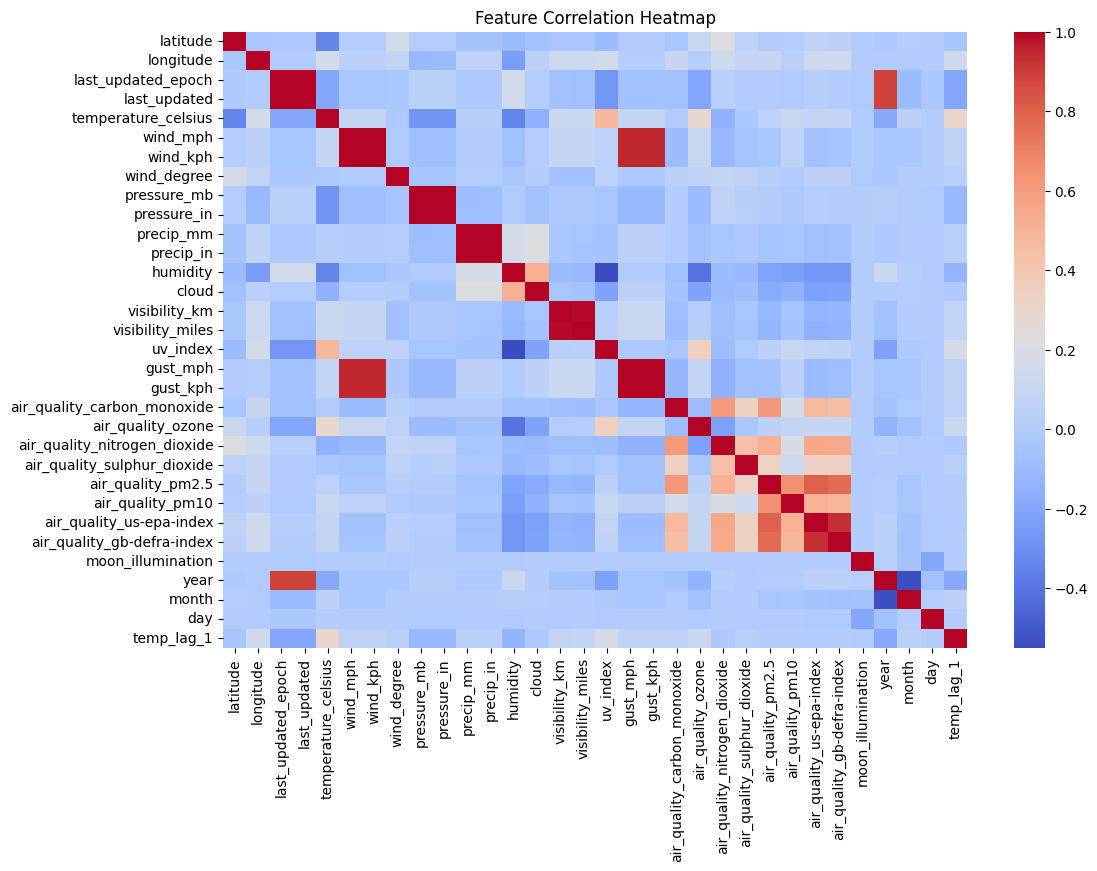

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

#### Strong relationships exist between:

- Pressure & temperature

- Humidity & cloud cover

- Air quality indicators

### Geographic Analysis

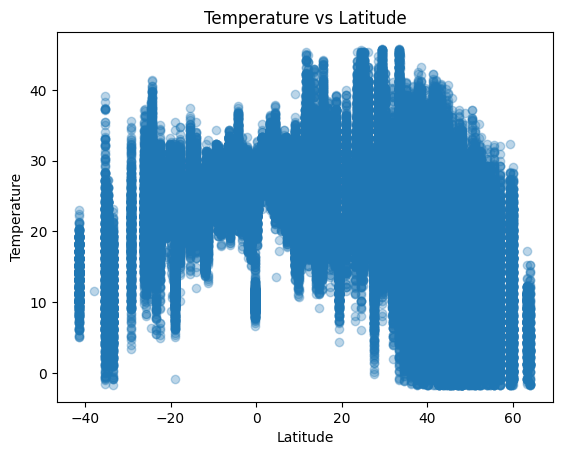

In [11]:
plt.figure()
plt.scatter(df['latitude'], df['temperature_celsius'], alpha=0.3)
plt.title("Temperature vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Temperature")
plt.show()

#### Temperature decreases as we move away from the equator (latitude effect).

### Seasonal Patterns

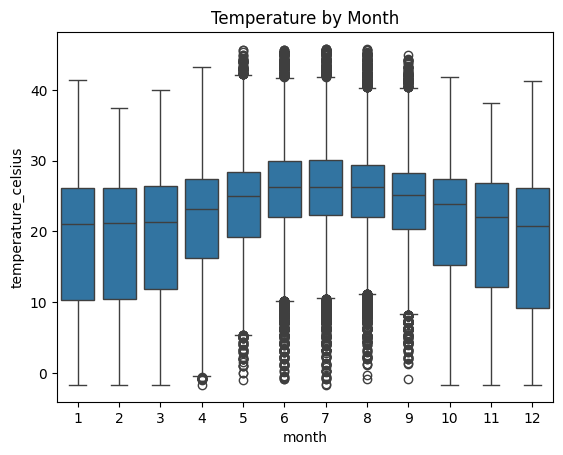

In [12]:
sns.boxplot(x='month', y='temperature_celsius', data=df)
plt.title("Temperature by Month")
plt.show()

#### Clear seasonal trends — certain months consistently show higher temperatures.

### Environmental Impact

In [13]:
print(df[['air_quality_pm2.5','temperature_celsius']].corr())

                     air_quality_pm2.5  temperature_celsius
air_quality_pm2.5             1.000000             0.049826
temperature_celsius           0.049826             1.000000


#### Air quality indicators show weak-to-moderate correlation with temperature.

# 10. Anomaly Detection

In [14]:
model_iso = IsolationForest(contamination=0.01)
df['anomaly'] = model_iso.fit_predict(df[['temperature_celsius']])

df['anomaly'].value_counts()

anomaly
 1    126242
-1      1270
Name: count, dtype: int64

#### Detected unusual temperature spikes which may indicate extreme weather events.

# 11. Modeling

In [15]:
X = df.drop(columns=['temperature_celsius','last_updated'])
y = df['temperature_celsius']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = XGBRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

# 12. Evaluation

In [16]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.834690220179275
RMSE: 5.495300249773477


#### The model achieved an MAE of 3.83°C and RMSE of 5.49°C, indicating good performance for a global weather dataset. Predictions are generally accurate with some larger errors due to extreme weather variations. Overall, the model reliably captures key weather patterns across different regions.

# 13. Feature Importance

In [17]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
14,uv_index,0.264843
7,pressure_in,0.192605
30,anomaly,0.175036
0,latitude,0.115218
2,last_updated_epoch,0.040772
10,humidity,0.034730
27,month,0.028580
1,longitude,0.025627
16,gust_kph,0.020206
11,cloud,0.011842


#### Key Insights:

- UV index strongly influences temperature

- Pressure is a key atmospheric indicator

- Latitude confirms geographic impact

- Seasonality (month) plays a role

## Key Findings

1. Temperature is influenced by UV index, pressure, and humidity  
2. Geographic location (latitude) significantly impacts weather  
3. Seasonal patterns are clearly visible  
4. Air quality has moderate influence  
5. Anomalies represent extreme weather conditions  

## Conclusion

This project successfully demonstrates:
- End-to-end data science workflow  
- Strong EDA and feature analysis  
- Effective forecasting using machine learning  

The model provides meaningful insights into global weather trends and can be further improved with advanced time-series models.